#Day 35 - Exploring Machine Learning Models with Python Advanced Classification Techniques
Student: **Daud Rusyad Nurdin**, *bootcamp DA/DS 34*

## Indikator penilaian
## Wajib di google colab, jika tidak di google colab ada pengurangan nilai -5
## Pengerjaan harus sesuai template yang disediakan, jika tidak ada pengurangan nilai -5 (untuk memudahkan membaca code)
## share to arifromadhan19@gmail.com

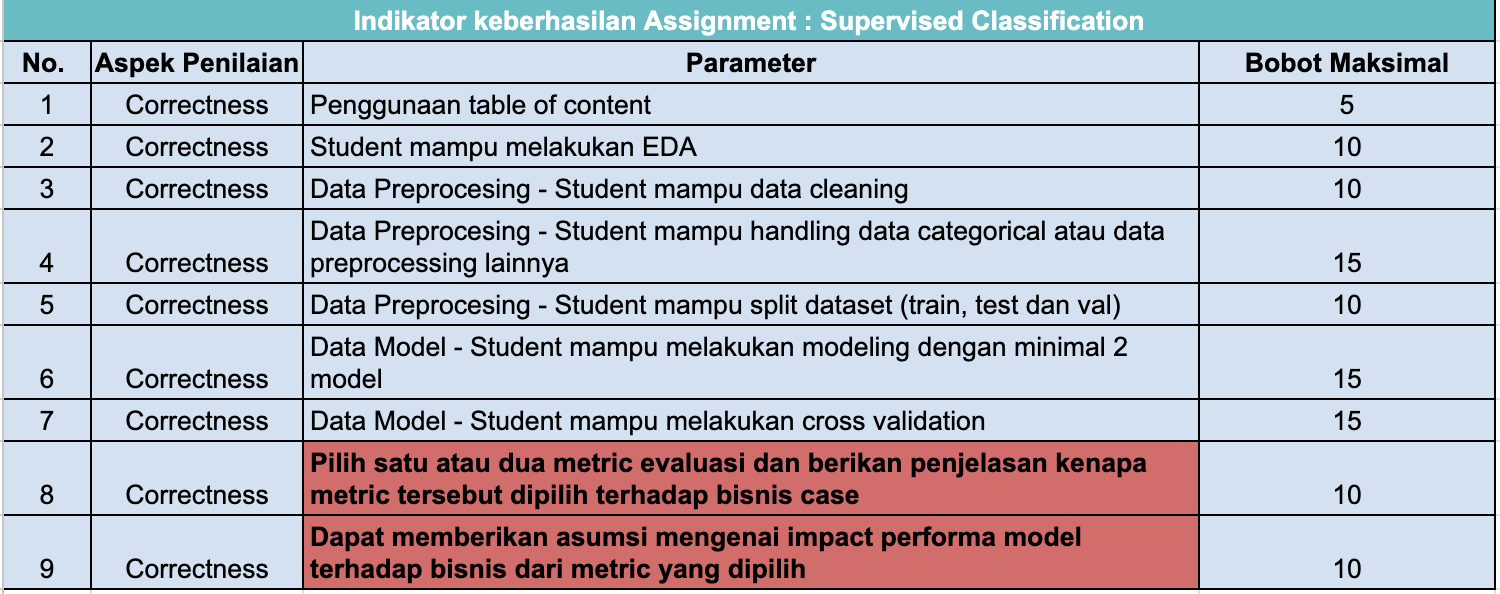

## Import Library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from imblearn.over_sampling import SMOTE

from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

# add new libs
from sklearn.ensemble import GradientBoostingClassifier
from IPython.display import Markdown, display

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True) # add command: ", force_remount=True" to avoid warning

# here is my data stored...
data_path = '/content/drive/My Drive/Dibimbing/Day 35 - Python Advanced Classification Techniques/'

Mounted at /content/drive/


## Load dataset

In [ ]:
df_ori = pd.read_csv(data_path + 'TelcoCustomerChurn.csv')
df_ori.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df_ori.info() # sampai di sini seolah2 tidak ada nilai null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Catatan:**
* Terdapat 18 object (categorical) --> tetapi seharusnya TotalCharges = numerical
* Terdapat 3 kolom numerikal --> tetapi seharusnya SeniorCitizen - categorical \
--> convert tipe data TotalCharges dari object ke numerik \
--> convert tipe data SeniorCitizen dari integer ke string
* Periksa kembali nilai null di kolom --> jika ada: imputasi
* Periksa data duplikat --> Jika ada maka buang
* Periksa outlier untuk data numerik --> jika mungkin, dibuang barisnya.
* Buang kolom yang tidak diperlukan --> CustomerID dibuang karena tidak diperlukan pada saat modeling

**Tugas:**
* Membuat model prediktif (dengan 2 model Machine Learning) untuk memprediksi apakah fakta/data baru: CHURN/TIDAK --> maka pada data set di atas kolom Churn merupakan target.

##Data Cleaning

###**Convert data type: TotalCharges & SeniorCitizen**

In [ ]:
'''
  convert tipe data TotalCharge dari object ke numerik
  convert tipe data SeniorCitizen dari integer ke string
'''
df = df_ori # copy data ori, selanjutnya df2
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

In [ ]:
df['Churn'].value_counts() # imbalance

,count
Churn,
No,5174
Yes,1869


Catatan:
* Data imbalance dengan dimana Churn merupakan Minoritas, dan UnChurn mayoritas.
* Imbalance data tergambar juga pada saat EDA.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# null values
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**Catatan:**
* Setelah di-convert tipe data dari kedua kolom di atas, TotalCharges mengandung nilai null (11 rekord) --> imputasi: karena numerikal, isi dengan median --> Dilakukan di tahap **Data PreProcessing**

###**Check duplicate data**

In [ ]:
# Periksa data duplikat
dupl = df[df.duplicated()]
dupl

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


**Catatan:**
* Tidak ditemukan duplikasi data, setidaknya berdasarkan CustomerID

###**Drop unnecessary column: CustomerID**
* Telah dijelaskan di atas, jika kolom ini tidak diperlukan dalam analisa dan tidak ada juga yang menyebabkan duplikasi karena nilai pada kolom CustomerID ini.
* Mengapa drop kolom dilakukan di belakang, sebab jika dilakukan di depan, kemudian ada pengecekan data duplikat akan muncul seolah-seolah data duplikat, padahal bukan, karena secara CustomerID tetap unik.

In [ ]:
'''
  Drop kolom CustomerID, karena tidak relevan untuk keperluan tugas ini.
'''
df.drop('customerID',axis=1,inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


###**Check outliers: tenure, MonthlyCharges, TotalCharges**

In [ ]:
# Catat kolom2 kategorikal dan numerikal
cat_cols=list(df.select_dtypes(include=['object']).columns)
num_cols=list(df.select_dtypes(include=['number']).columns)

In [ ]:
print(cat_cols)
print(num_cols)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
['tenure', 'MonthlyCharges', 'TotalCharges']


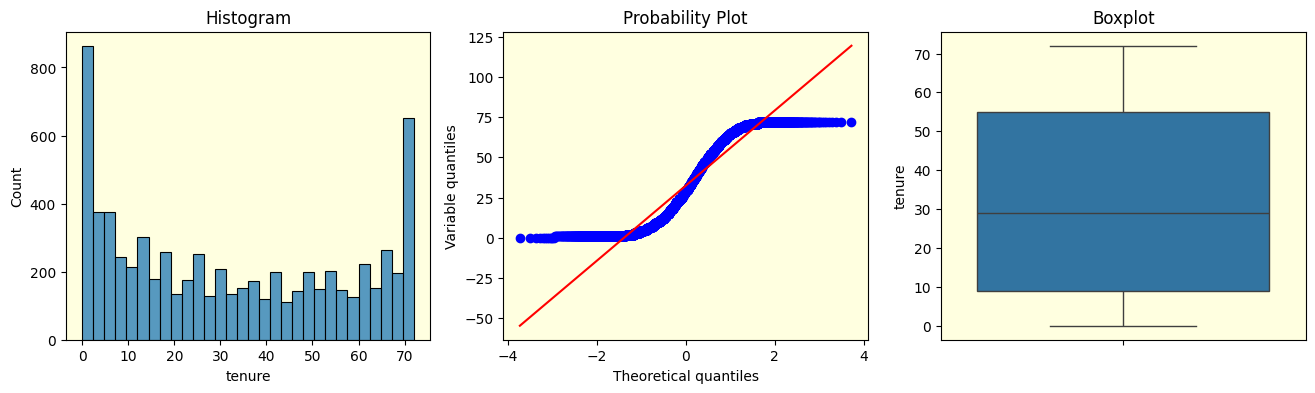

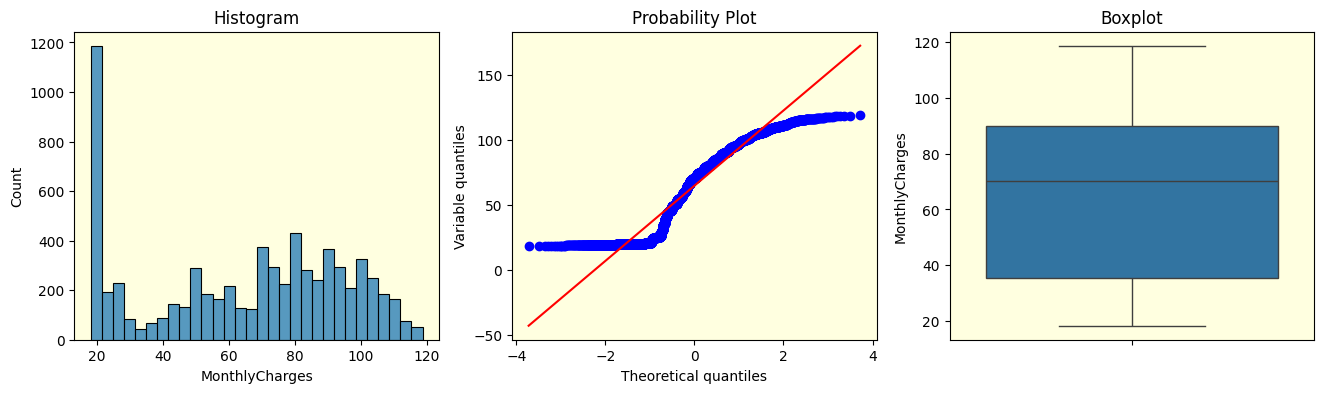

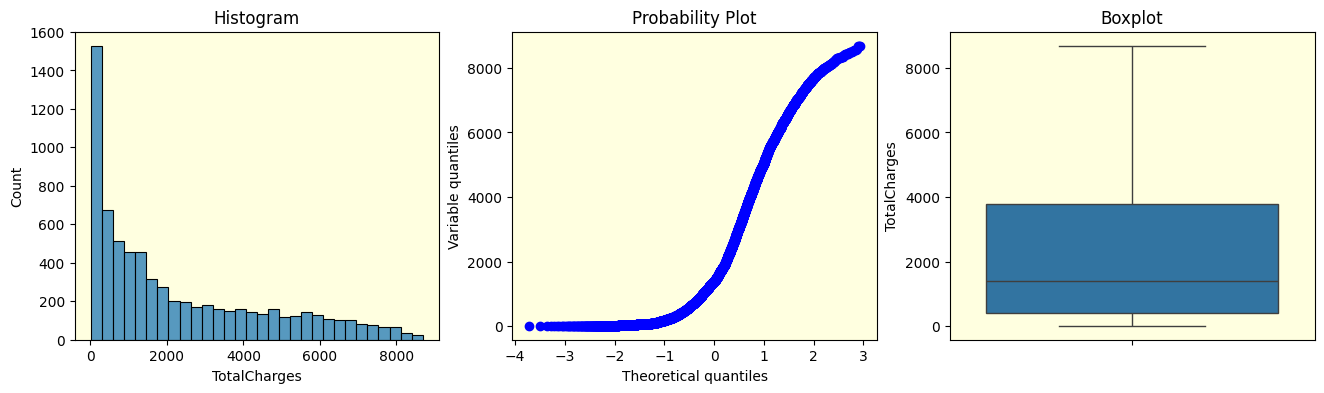

In [ ]:
import scipy.stats as stats

cols = num_cols

# fungsi untuk plotting
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')
    plt.gca().set_facecolor('lightyellow')  # kuning muda

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')
    plt.gca().set_facecolor('lightyellow')  # kuning muda

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')
    plt.gca().set_facecolor('lightyellow')  # kuning muda

    plt.show()

for col in num_cols:
    check_plot(df, col)

**Catatan:**
* Tidak ada outlier --> tidak perlu handling outliers

##Data Prepocessing

###**Imputasi nilai null pada TotalCharges dengan nilai median**

In [ ]:
# Isi nilai null pada TotalCharges dengan nilai mediannya
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
df.info() # sudah tidak ada null pada TotalCharges

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


###**Encoding categorical columns**

In [ ]:
# Catat kolom2 kategorikal dan numerikal --> setelah data cleaning
cat_cols=list(df.select_dtypes(include=['object']).columns)

# Encoding categorical columns
from sklearn.preprocessing import LabelEncoder

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

label_encoder = LabelEncoder()
for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## EDA (Exploratory Data Analysis)

###**Churn & Unchurn Proportion**

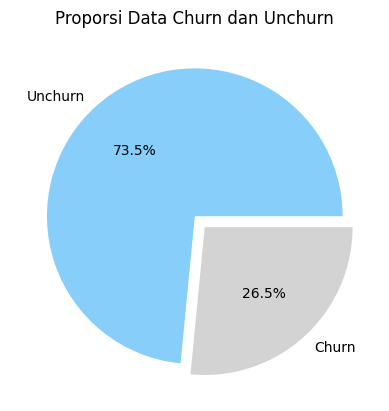

In [ ]:
# Hitung proporsi churn dan unchurn
churn_count = df['Churn'].value_counts()
labels = ['Unchurn', 'Churn']
sizes = [churn_count[0], churn_count[1]]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightskyblue', 'lightgrey'], explode=(0, 0.1))
plt.title('Proporsi Data Churn dan Unchurn')
plt.show()

**Catatan:**
* Data imbalance --> Kemungkinan perlu dilakukan oversampling (bukan undersampling, karena datanya sedikit) --> Gunakan SMOTE agar lebih bagus, sampling data yang dibuat.

###**Distribution of Data: tenure, MonthlyCharges & TotalCharges**

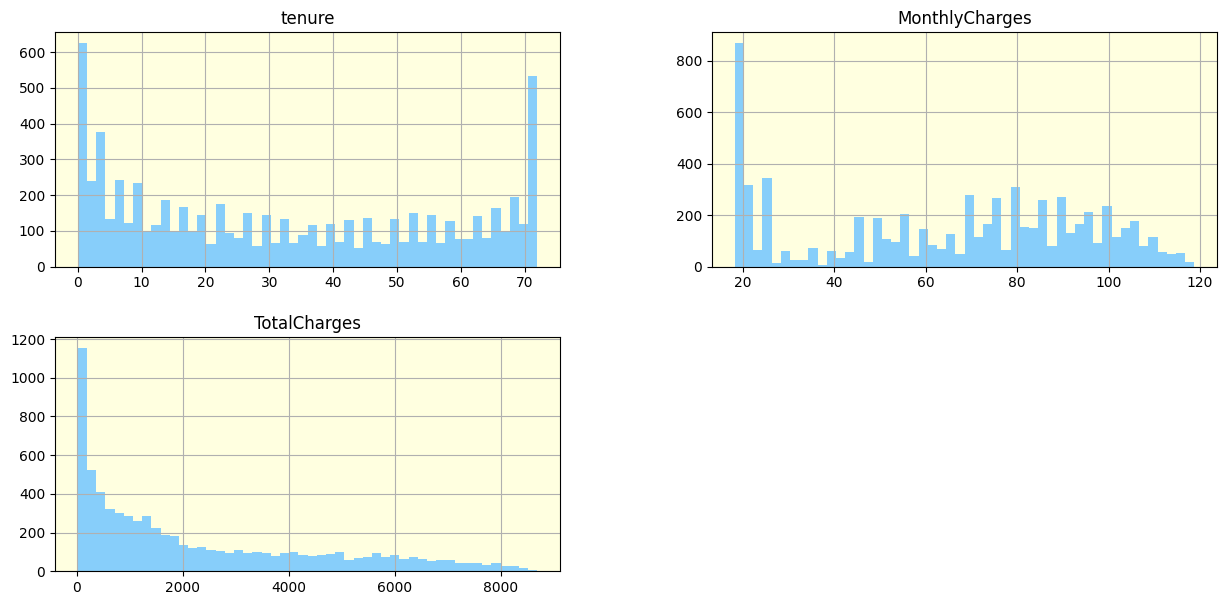

In [ ]:
df[num_cols].hist(bins=50, figsize=(15, 7), color='lightskyblue')
for ax in plt.gcf().axes:
    ax.set_facecolor('lightyellow')  # kuning muda
plt.show()

###**Churn by Gender**

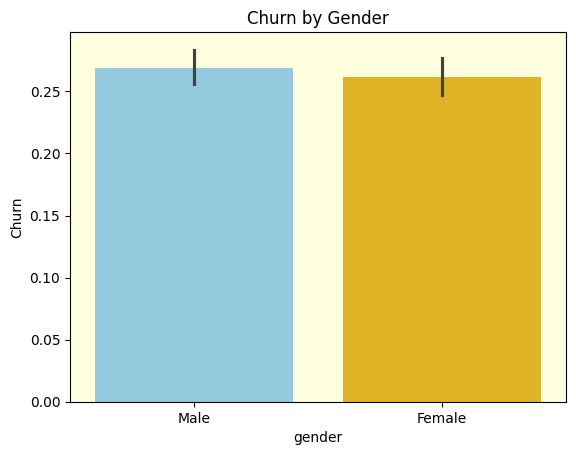

In [ ]:
sns.barplot(data=df_ori, x='gender', y='Churn', palette=['#87CEEB', '#FFC107'])
# plt.legend(title='Gender', labels=['Male', 'Female'], loc='upper right', bbox_to_anchor=(1.05, 1))
plt.gca().set_facecolor('lightyellow')  # kuning muda
plt.xticks([0, 1], ['Male', 'Female'])
plt.title('Churn by Gender')
plt.show()

###**Correlation amongst numerical predictors**

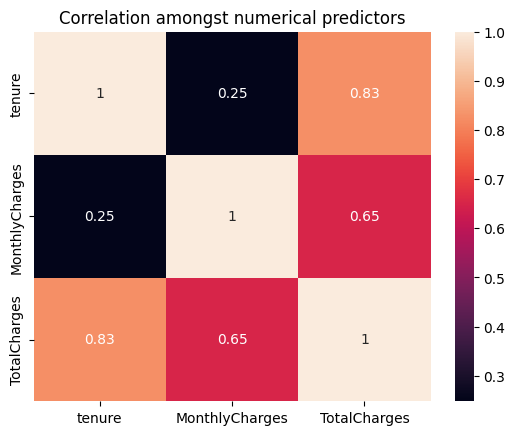

In [ ]:
# Mencari korelasi antara kolom-kolom numerik
corr_num=df[num_cols].corr()
sns.heatmap(corr_num,annot=True)
plt.title('Correlation amongst numerical predictors')
plt.show()

**Catatan:**
* Meskipun terdapat korelasi yang cukup tinggi di sini antara MonthlyCharges dan TotalCharges, tetapi karena yang diujicoba adalah model berbasis tree, maka kolom-kolom tersebut tidak perlu dihapus --> Secara teori: Tree-based model bisa menangani fitur yang berkorelasi tanpa masalah besar. ==> Tidak ada kolom didrop/dihapus.

###**Predictors correlation with churn**

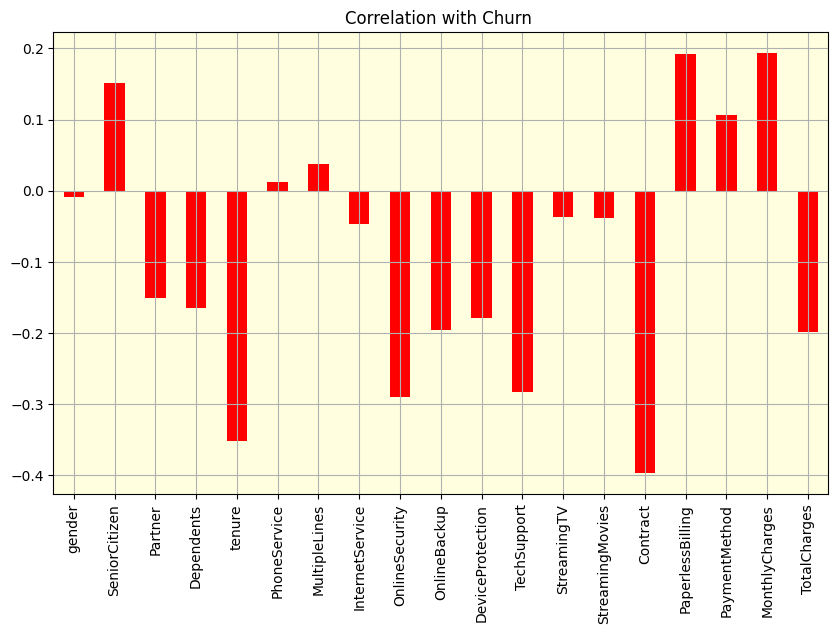

In [ ]:
# Korelasi prediktor dengan churn
df.drop('Churn',axis=1).corrwith(df.Churn).plot(kind='bar',grid=True,figsize=(10,6),title="Correlation with Churn ", color='red')
plt.gca().set_facecolor('lightyellow')  # kuning muda
plt.show()

**Catatan:**
* Semakin menjauh dari NOL berarti korelasi prediktor tersebut semakin tinggi dengan Churn.
* Nilai negatif : korelasi negatif, semakin negatif --> semakin kecil peluangnya untuk Churn. Misal: tenure dan contract menunjukkan korelasi negatif yang tinggi.
* Nilai positif: korelasi positif, semakin positif --> semakin besar peluangnya untuk Churn. Faktor churn yang tinggi pada prediktor: PaperlessBiling dan MonthlyCharges.

##Split predictors and target data
* x is predictors
* y is target

In [ ]:
x = df.drop(columns=['Churn'],axis=1)
y = df['Churn']

In [ ]:
y.value_counts()# imbalance: 0=No, 1=Yes

,count
Churn,
0,5174
1,1869


Catatan:
* Dari data di atas menunjukkan bahwa data tidak seimbang (imbalance).
* Di bawah akan diuji bagaimana pengaruh data imbalance terhadap model yang dibuat, dan bagaimana pengaruhnya jika dilakukan treatment terhadap data ini, yakni dengan cara oversampling, mengingat datanya tidak terlalu besar. --> dari EDA bisa dilihat 73,5% = unchurn dan 26,5% = churn.

##Modeling
* Mulai dari sini akan dilakukan eksperimen terhadap 2 model yang dipilih, yakni: **Random Forest** dan **Gradient Boosting**.

###**Testing Scnenario**
* Splitting data original imbalance. --> Train : Test dengan proporsi 80:20, dan random_state=42 (yang paling umum digunakan)
* Definisikan model dengan nilai parameter yang ditentukan.
* Train model dengan menggunakan data train.
* Test model yang telah dilatih sebelumnya dengan menggunakan data test.
* Evaluasi kinerja model. --> digunakan method: classification_report.
  - **Precision**: Rasio antara true positive (TP) dan jumlah prediksi positif (TP + FP). Nilai precision yang tinggi menunjukkan bahwa model memiliki kemampuan yang baik dalam mengklasifikasikan sampel positif.
  - **Recall**: Rasio antara true positive (TP) dan jumlah sampel positif sebenarnya (TP + FN). Nilai recall yang tinggi menunjukkan bahwa model memiliki kemampuan yang baik dalam mengklasifikasikan sampel positif yang sebenarnya.
  - **F1-score**: Rata-rata harmonik antara precision dan recall. Nilai F1-score yang tinggi menunjukkan bahwa model memiliki kinerja yang baik dalam mengklasifikasikan sampel positif dan negatif.
  - **Support**: Jumlah sampel pada setiap kelas.
  - **Accuracy**: mengukur proporsi prediksi yang benar dari semua prediksi yang dibuat oleh model.
* Lakukan oversampling, kembali train model, test model dan evaluation.
* Terakhir, lakukan cross-validation, test model dan evaluation.
* Buat kesimpulan kinerja dari kedua model tersebut.


###**Splitting data: train and test**

In [ ]:
# x means predictors
# y means target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Report splitting
display(Markdown("**Before split:**"))
print(f'the shape of x is       : {x.shape}')
print(f'the shape of y is       : {y.shape}')
print("\n")
display(Markdown("**After split:**"))
print(f'the shape of x_train is : {x_train.shape}')
print(f'the shape of x_test is  : {x_test.shape}')
print(f'the shape of y_tain is  : {y_train.shape}')
print(f'the shape of y_test is  : {y_test.shape}')

**Before split:**

the shape of x is       : (7043, 19)
the shape of y is       : (7043,)




**After split:**

the shape of x_train is : (5634, 19)
the shape of x_test is  : (1409, 19)
the shape of y_tain is  : (5634,)
the shape of y_test is  : (1409,)


###**Random Forest - with imbalance Data**

####Define and train model
* Set parameters of model
* Train model using data train

In [ ]:
'''
  Nilai-nilai parameter di sini hanya diambil sembarang,
  jadi tidak ada percobaan untuk menemukan nilai yang terbaik.
  Kedepannya mungkin bisa dilakukan uji nilai parameter yang
  paling optimal.
'''
# Define parameter
ne = 100 # number of trees
mss = 2 # minimum samples split
rs = 42 # random state - common used

# Define model
rf = RandomForestClassifier(
    n_estimators = ne,
    max_depth = None,  # kedalaman pohon
    min_samples_split = mss,
    random_state = rs
)

# Train model
model_rf = rf.fit(x_train, y_train)

####Test model
* Test the trained model using data test.

In [ ]:
# Test model
y_pred = model_rf.predict(x_test)

####Evaluate model

In [ ]:
# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



**Insight:**
* Precision 0.66 (churn) → dari semua prediksi churn, 66% benar-benar churn.
* Recall 0.47 (churn) → model hanya menangkap 47% dari seluruh pelanggan yang benar-benar churn.
* F1-score 0.55 (churn) → keseimbangan antara precision dan recall, cukup rendah.
* Accuracy 0.80 → terlihat cukup tinggi, tapi karena dataset imbalanced, accuracy bisa menipu.

**Kesimpulan:**
* Model cenderung lebih bagus memprediksi pelanggan tidak churn, tapi kurang sensitif menangkap churn (kelas minoritas).

###**Gradient Boosting - with imbalance Data**

####Define and train model

In [ ]:
'''
  Nilai-nilai parameter di sini hanya diambil sembarang,
  jadi tidak ada percobaan untuk menemukan nilai yang terbaik.
  Kedepannya mungkin bisa dilakukan uji nilai parameter yang
  paling optimal.
'''
# Define parameters
md = 5 # max depth
lr = 0.1 # learning rate
ne = 100 # number of estimators

# Define model
gb = GradientBoostingClassifier(
    max_depth = md,
    learning_rate = lr,
    n_estimators = ne
)

# Train model without scaling
model_gb = gb.fit(x_train, y_train)

####Test model

In [ ]:
# Testing model with imbalance data
y_pred = model_gb.predict(x_test)

####Evaluation

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



**Insight:**
* Precision 0.66 (churn) → dari semua prediksi churn, 66% benar-benar churn.
* Recall 0.53 (churn) → model hanya menangkap 53% dari seluruh pelanggan yang benar-benar churn.
* F1-score 0.59 (churn) → keseimbangan antara precision dan recall, cukup rendah.
* Accuracy 0.80 → terlihat cukup tinggi, tapi karena dataset imbalanced, accuracy bisa menipu.

**Kesimpulan:**
* Model cenderung lebih bagus memprediksi pelanggan tidak churn, tapi kurang sensitif menangkap churn (kelas minoritas).

##Oversampling using SMOTE
* Secara teori data imbalance akan menghasilkan model yang kurang baik, maka pada tahap ini akan dilakukan oversampling data dengan SMOTE untuk melihat efek dari balancing data. --> di sini sampling data minoritas (CHURN) akan disamakan dengan mayoritas (UNCHURN).

In [ ]:
'''
  Berdasarkan hasil pengamatan/ percobaan, oversampling dengan SMOTE
  bisa meningkatkan akurasi prediksi > 10%
'''
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x, y = smote.fit_resample(x, y)

In [ ]:
y.value_counts()# imbalance: 0=No, 1=Yes

,count
Churn,
0,5174
1,5174


Catatan:
* Sampai di sini, jumlah data minoritas dan mayoritas sudah sama.

###**Splitting data: test and train, after oversampling-SMOTE**

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Report splitting
display(Markdown("**Before split:**"))
print(f'the shape of x is       : {x.shape}')
print(f'the shape of y is       : {y.shape}')
print("\n")
display(Markdown("**After split:**"))
print(f'the shape of x_train is : {x_train.shape}')
print(f'the shape of x_test is  : {x_test.shape}')
print(f'the shape of y_tain is  : {y_train.shape}')
print(f'the shape of y_test is  : {y_test.shape}')

**Before split:**

the shape of x is       : (10348, 19)
the shape of y is       : (10348,)




**After split:**

the shape of x_train is : (8278, 19)
the shape of x_test is  : (2070, 19)
the shape of y_tain is  : (8278,)
the shape of y_test is  : (2070,)


###**Random Forest - after oversampling-SMOTE**

####Define and train model

In [ ]:
# Define parameter
ne = 100 # number of trees
mss = 2 # minimum samples split
rs = 42 # random state - seed

# Define model
rf = RandomForestClassifier(
    n_estimators = ne,
    max_depth = None,  # kedalaman pohon
    min_samples_split = mss,
    random_state = rs
)

# Train model
model_rf = rf.fit(x_train, y_train)

####Test model

In [ ]:
# Test model
y_pred = model_rf.predict(x_test)

####Evaluation

In [ ]:
# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1021
           1       0.86      0.84      0.85      1049

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070



**Insight:**
* Precision 0.86 (churn) → dari semua prediksi churn, 86% benar-benar churn.
* Recall 0.84 (churn) → model menangkap 84% dari pelanggan yang benar-benar churn (perbaikan besar dari 0.47 sebelum SMOTE).
* F1-score 0.85 untuk kedua kelas → model kini seimbang antara kelas churn dan tidak churn.
* Accuracy 0.85 → lebih representatif sekarang karena data sudah seimbang.

**Kesimpulan:**
* SMOTE sangat efektif untuk mengatasi masalah imbalance di churn dataset.
* Model sekarang tidak bias ke kelas mayoritas, dan F1-score menjadi seimbang untuk kedua kelas.
* Prediksi churn jauh lebih dapat diandalkan.

###**Gradient Boosting - after oversampling-SMOTE**

####Define and train model

In [ ]:
'''
  Nilai-nilai parameter di sini hanya diambil sembarang,
  jadi tidak ada percobaan untuk menemukan nilai yang terbaik.
  Kedepannya mungkin bisa dilakukan uji nilai parameter yang
  paling optimal.
'''
# Define parameters
md = 5 # max depth
lr = 0.1 # learning rate
ne = 100 # number of estimators

# Define model
gb = GradientBoostingClassifier(
    max_depth = md,
    learning_rate = lr,
    n_estimators = ne
)

# Train model without scaling
model_gb = gb.fit(x_train, y_train)

####Test model

In [ ]:
# Test model
y_pred = model_gb.predict(x_test)

####Evaluation

In [ ]:
# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1021
           1       0.84      0.85      0.84      1049

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070



**Insight:**
* Precision 0.84 (churn) → dari semua prediksi churn, 84% benar-benar churn.
* Recall 0.85 (churn) → model menangkap 85% dari pelanggan yang benar-benar churn (perbaikan besar dari 0.53 sebelum SMOTE).
* F1-score 0.84 untuk kedua kelas → model kini seimbang antara kelas churn dan tidak churn.
* Accuracy 0.84 → lebih representatif sekarang karena data sudah seimbang.

**Kesimpulan:**
* SMOTE sangat efektif untuk mengatasi masalah imbalance di churn dataset.
* Model sekarang tidak bias ke kelas mayoritas, dan F1-score menjadi seimbang untuk kedua kelas.
* Prediksi churn jauh lebih dapat diandalkan.


Perbandingan kinerja Random Forest dan Gradient Boosting sebelum dan setelah dilakukan oversampling-SMOTE untuk prediksi CHURN:

**Before oversampling (Imbalance Data)**
| Model             | Precision |   Recall   |  F1-score  |  Accuracy  |
|-------------------|-----------|------------|------------|------------|
| Random Forest     |    66%    |    47%     |    55%     |     80%    |
| Gradient Boosting |    66%    |    53%     |    59%     |     80%    |

* Masalah utama: recall untuk kelas churn rendah (47–52%).
  - **Model kurang sensitif** menangkap pelanggan yang churn, karena jumlahnya lebih sedikit dibandingkan tidak churn.
* Accuracy 80% terlihat tinggi, **tapi menyesatkan karena kelas mayoritas mendominasi**.

**After oversampling (using SMOTE)**
| Model             | Precision |   Recall   |  F1-score  |  Accuracy  |
|-------------------|-----------|------------|------------|------------|
| Random Forest     |    86%    |    84%     |    85%     |     85%    |
| Gradient Boosting |    84%    |    85%     |    84%     |     84%    |

* Recall churn naik drastis (84–86%) → model kini lebih baik menangkap pelanggan yang benar-benar churn.
* F1-score seimbang antara kelas 0 dan 1 → performa prediksi lebih stabil.
* Accuracy sedikit naik (84-85%) → sekarang lebih representatif karena imbalance sudah diperbaiki.

**Insight**
1. Oversampling (SMOTE) efektif untuk data churn yang imbalance.
2. Random Forest vs Gradient Boosting:
   - F1-score hampir seimbang, Random Forest sedikit lebih tinggi (85% vs 84%).
   - Keduanya bisa digunakan, tergantung preferensi interpretasi dan kecepatan training.
5. Untuk produksi/prediksi nyata, **model setelah SMOTE jelas lebih reliable untuk mendeteksi churn**.

##Cross Validation
* Selanjutnya akan diuji denga Cross-Validation untuk melihat seberapa stabil model-model tersebut.
* Di sini data yang digunakan adalah data yang sudah di-oversampling, karena data imbalance sudah jelas-jelas kinerjanya kurang bagus.
* Di sini tidak ada uji perubahan nilai parameter, baik pada saat training model, ataupun cross validation.

###**Scaling data, is it still needed?**
* Proses Scaling tidak diperlukan karena Tree-based model (Random Forest / Gradient Boosting):
  - Membagi data berdasarkan threshold pada fitur (misal MonthlyCharges > 70).
  - Jadi skala fitur tidak memengaruhi split → prediksi tetap sama meski fitur di-scale.

###**Random Forest: Cross Validation**
* Jumlah folds yang digunakan dalam cross-validation di sini sebanyak 5 --> cv=5. Di sini, tidak ada pengujian lebih jauh dengan melakukan perubahan nilai cv, karena data tidak terlalu banyak, serta semakin tinggi nilai cv, maka proses cross-validation akan semakin lama. Untuk data yang besar, mungkin perlu dipertimbangan dengan nilai cv yang lebih tinggi.
* Dalam kasus ini, data x_train_ss dan y_train akan dibagi menjadi 5 subset, dan model akan dilatih pada 4 subset dan diuji pada 1 subset yang tersisa.
* Proses ini akan diulangi 5 kali sehingga setiap subset akan menjadi subset uji sekali.

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation dengan f1_score sebagai metric
cv_scores = cross_val_score(model_rf, x_train_ss, y_train, cv=5, scoring='f1')

# Print hasil
print("F1-score, cv=5    :", cv_scores)
print("F1-score rata-rata:", cv_scores.mean())

F1-score, cv=5    : [0.84249084 0.82562278 0.86476653 0.84191399 0.84804805]
F1-score rata-rata: 0.8445684366053321


**Analisis:**
* F1-score per fold (cv=5): [0.84249084 0.82562278 0.86476653 0.84191399 0.84804805]
  - Variasi antar fold kecil → model stabil dan tidak overfit pada satu split tertentu.
* Rata-rata F1-score ≈ 0.845
  - Ini konsisten dengan hasil evaluasi sebelumnya setelah SMOTE (~0.85).
  - Menunjukkan model mampu menangkap churn dengan baik.

**Kesimpulan:**
* Random Forest dengan SMOTE memberikan performa solid dan stabil.
* F1-score yang seimbang antara kelas 0 dan 1 → model cukup reliable untuk prediksi churn.

####Test model

In [ ]:
# Test model
y_pred = model_rf.predict(x_test)

####Evaluation

In [ ]:
# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1021
           1       0.86      0.84      0.85      1049

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070



**Catatan:**
* Kinerja model secara semua metrik yang diuji menunjukkan stabilitas yang bagus.

###**Gradient Boosting: Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation dengan f1_score sebagai metric
cv_scores = cross_val_score(model_gb, x_train_ss, y_train, cv=5, scoring='f1')

# Print hasil
print("F1-score, cv=5    :", cv_scores)
print("F1-score rata-rata:", cv_scores.mean())

F1-score, cv=5    : [0.85075529 0.8317757  0.85149701 0.84587814 0.84895522]
F1-score rata-rata: 0.8457722708025962


**Catatan:**
Analisis dan Kesimpulan kurang lebih sama dengan model Random Forest. Model menunjukkan stabilitas yang cukup bagus.

####Test model

In [ ]:
# Test model
y_pred = model_gb.predict(x_test)

####Evaluation

In [ ]:
# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1021
           1       0.84      0.85      0.84      1049

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070



**Catatan:**
* Kinerja model secara semua metrik yang diuji menunjukkan stabilitas yang bagus.

##Potential impact

* Di atas (sebelumnya) telah ditunjukkan bahwa kinerja prediksi data UnChurn selalu bagus dikarenakan data sampel yang mayoritas. Sementara untuk prediksi Churn tidak bagus untuk data tidak seimbang (imbalance).
* Karena demikian, kemudian dilakukan uji model dengan melakukan oversampling-SMOTE, dan hasilnya menunjukkan kinerja model yang bagus, bahkan stabil.
* Langkah terakhir, dilakukan Cross-Validation dengan, untuk memastikan bahwa kinerja model benar-benar stabil.

Berikut adalah tabel perbandingan untuk prediksi Churn dari setiap tahap yang telah dilakukan.

**Before oversampling (Imbalance Data)**
| Model             | Precision |   Recall   |  F1-score  |  Accuracy  |
|-------------------|-----------|------------|------------|------------|
| Random Forest     |    66%    |    47%     |    55%     |     80%    |
| Gradient Boosting |    66%    |    53%     |    59%     |     80%    |

**After oversampling (using SMOTE)**
| Model             | Precision |   Recall   |  F1-score  |  Accuracy  |
|-------------------|-----------|------------|------------|------------|
| Random Forest     |    86%    |    84%     |    85%     |     85%    |
| Gradient Boosting |    84%    |    85%     |    84%     |     84%    |

**After Cross-Validation**
| Model             | Precision |   Recall   |  F1-score  |  Accuracy  |
|-------------------|-----------|------------|------------|------------|
| Random Forest     |    86%    |    84%     |    85%     |     85%    |
| Gradient Boosting |    84%    |    85%     |    84%     |     84%    |

Berikut kesimpulannya:

1. Sebelum oversampling (Imbalanced Data)
   * Random Forest dan Gradient Boosting memiliki precision/recall rendah untuk churn (kelas minoritas):
   * Recall hanya 47–53% → banyak churn tidak terdeteksi.
   * Accuracy terlihat tinggi (~80%), tapi menyesatkan karena kelas mayoritas mendominasi.
   * Kesimpulan: model bias ke kelas mayoritas, kurang efektif untuk mendeteksi churn.

2. Setelah oversampling (SMOTE)
   * SMOTE berhasil menyeimbangkan distribusi kelas di training set.
   * F1-score naik signifikan untuk kedua model (~84–85%).
   * Recall churn meningkat drastis (84–85%) → model lebih sensitif menangkap churn.
   * Precision tetap tinggi → prediksi churn lebih dapat diandalkan.
   * Accuracy sedikit meningkat (84–85%) → representatif untuk kedua kelas.

3. Setelah Cross-Validation
   * Hasil F1-score dan metrics lain konsisten dengan hasil SMOTE train/test split:
   * Random Forest F1 ≈ 85%
   * Gradient Boosting F1 ≈ 84%
   * Variasi antar fold kecil → model stabil dan tidak overfit pada split tertentu.

4. Kesimpulan Umum
   * Imbalance data menyebabkan performa buruk untuk kelas minoritas → perlu oversampling atau penyesuaian class weight (pada tugas ini, digunakan oversampling).
   * SMOTE efektif meningkatkan recall & F1-score untuk churn.
   * Cross-validation menegaskan model stabil dan performa konsisten.
   * Random Forest vs Gradient Boosting:
     - Performa hampir seimbang.
     - Random Forest sedikit lebih tinggi F1-score (85% vs 84%).
     - **Keduanya layak dipakai untuk prediksi churn.**

**Terima kasih**